<a href="https://colab.research.google.com/github/smonodeep/DynamicValuationGovernance/blob/main/0.Data_Prep_CityWise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

City Wise logic for data preparation


End-to-End Data Pipeline: Chain-Linked RBI HPI + Rent + Repo
This notebook constructs a unified panel dataset at the city–quarter level, combining various real estate and economic indicators as per the problem description.


# RBI HPI Chain Logic


Exported 76 link diagnostics to hpi_link_diagnostics.csv
--- Validation Checks ---
Missing HPI by City:
                   city  missing_hpi
10                kochi           48
2            chandigarh           15
17   thiruvananthapuram           15
15                 pune           15
7             hyderabad           15
5   gautam buddha nagar           15
14               nagpur           15
6             ghaziabad           15
16                thane           15
0             ahmedabad            0
1             bangalore            0
8                jaipur            0
3               chennai            0
4                 delhi            0
9                kanpur            0
13               mumbai            0
11              kolkata            0
12              lucknow            0

Duplicate City-Quarter Counts (after final processing):
No duplicate city-quarter combinations found.

Extreme HPI Growth Jumps (abs > 0.25):
        city  quarter         hpi  hpi_growth
537 

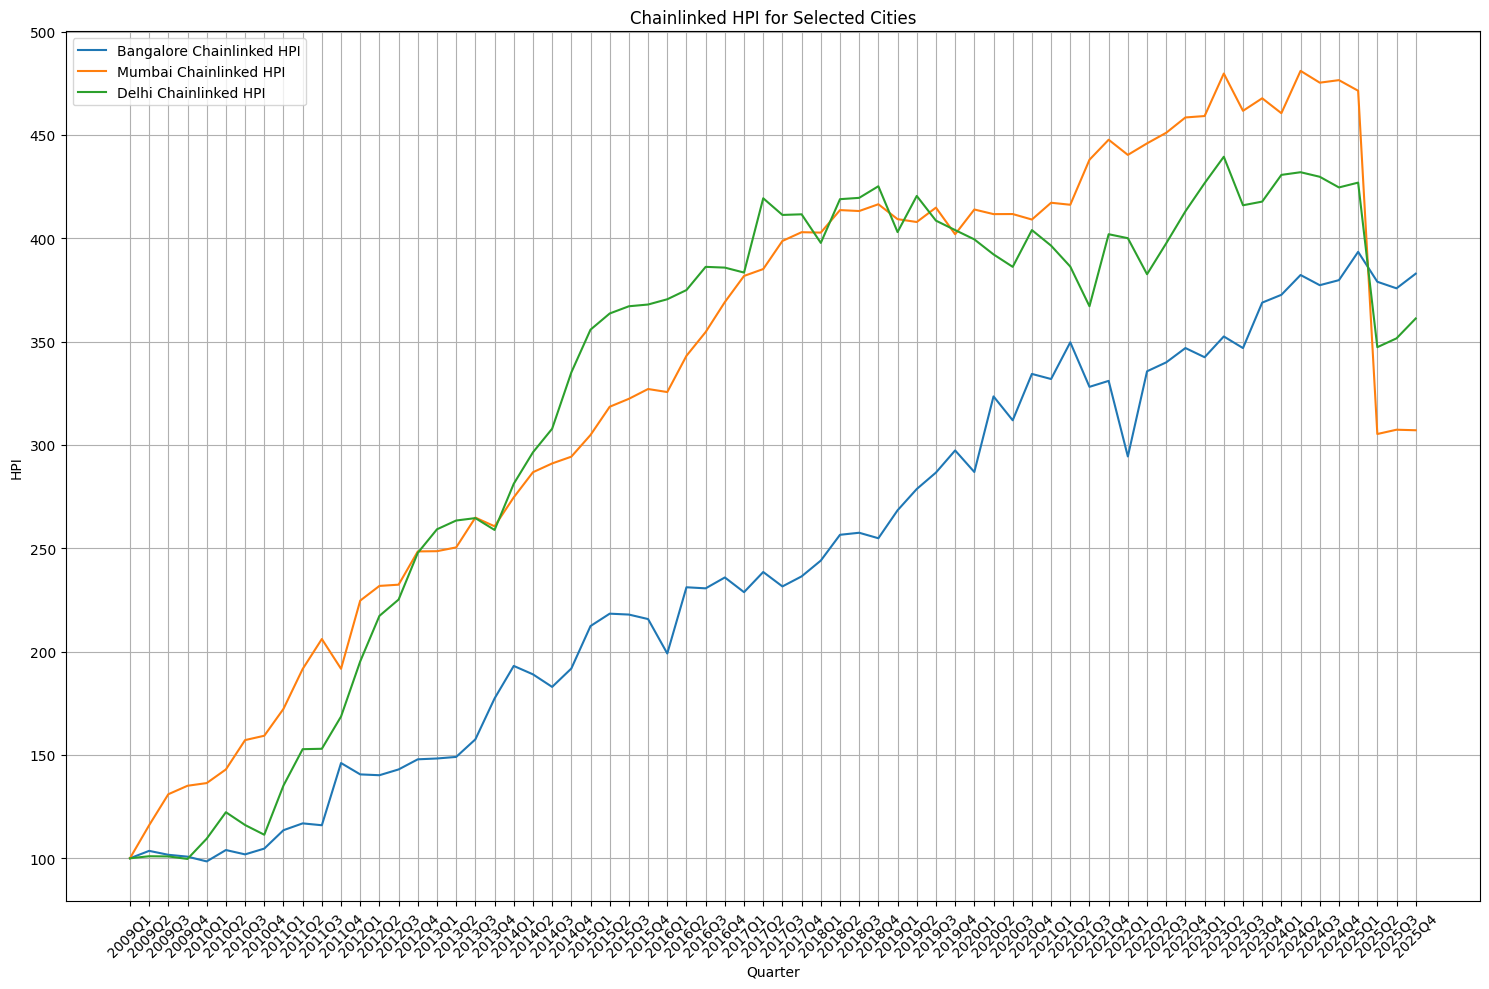

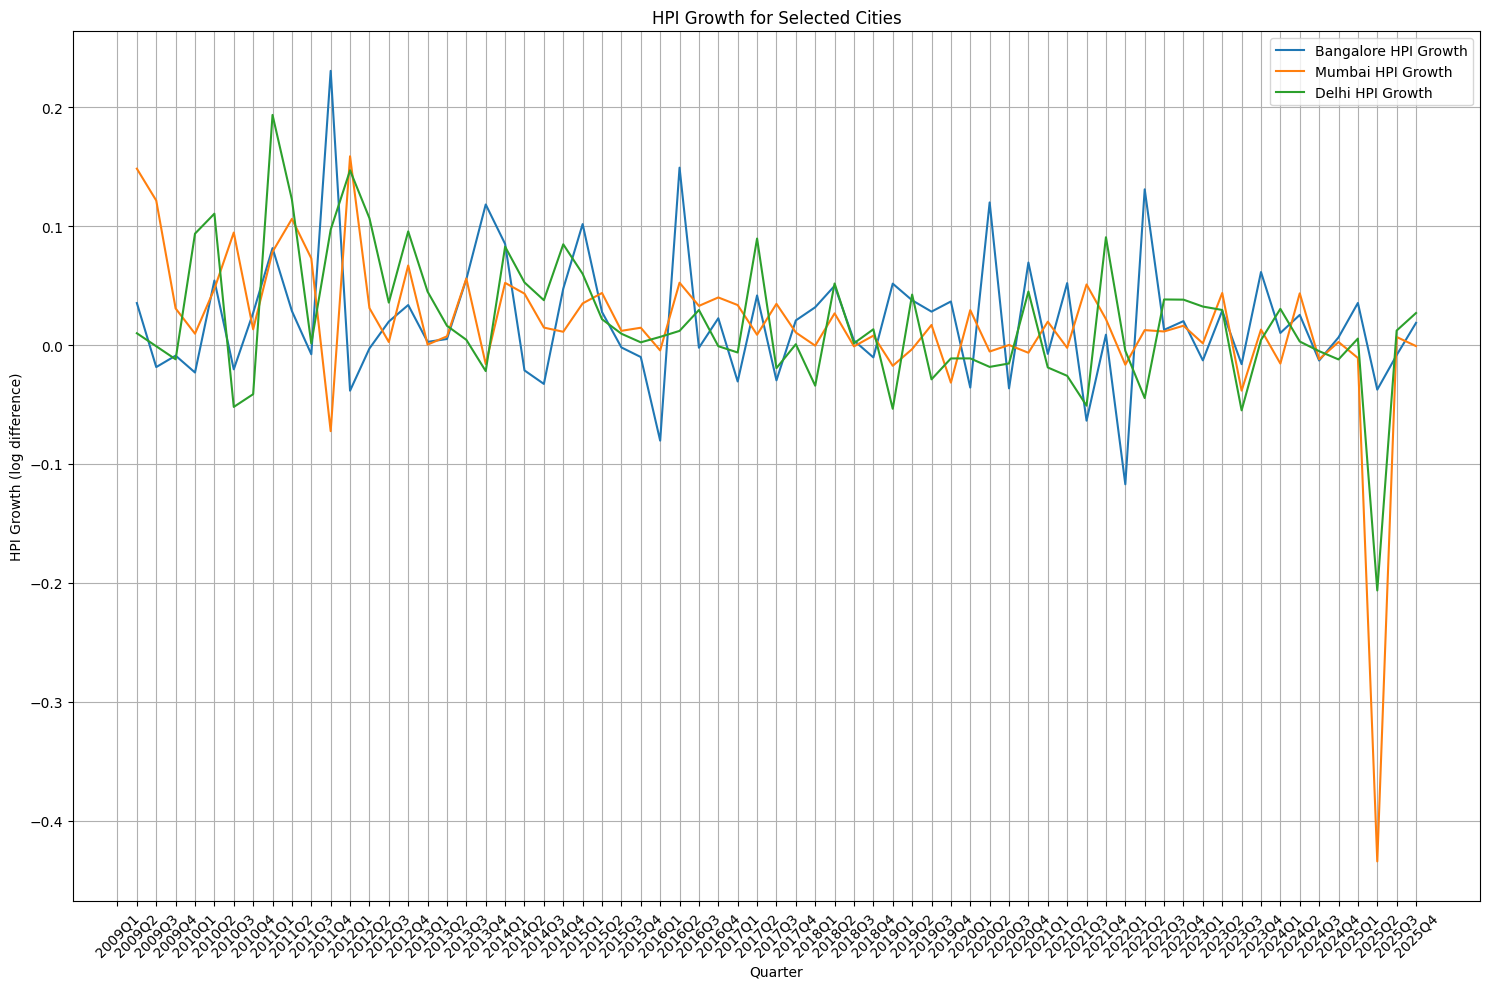

Saved: /content/rbi_hpi_chainlinked.csv
Saved: /content/rbi_hpi_chainlinked_with_growth.csv
Saved: /content/final_model_dataset.csv

--- Final Summary ---
1. Final dataset shape: (795, 9)
2. Number of cities: 18
3. Duplicate count (city-quarter, after cleaning): 0
4. Missing HPI summary:
                    city  missing_hpi
10                kochi           48
2            chandigarh           15
17   thiruvananthapuram           15
15                 pune           15
7             hyderabad           15
5   gautam buddha nagar           15
14               nagpur           15
6             ghaziabad           15
16                thane           15
0             ahmedabad            0
1             bangalore            0
8                jaipur            0
3               chennai            0
4                 delhi            0
9                kanpur            0
13               mumbai            0
11              kolkata            0
12              lucknow            0
5. Larg

In [21]:
# -------------------------------------------------------
# SECTION 1 - IMPORTS
# -------------------------------------------------------
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

# -------------------------------------------------------
# SECTION 2 - LOAD RBI HPI EXCEL
# -------------------------------------------------------
file_path = "/content/House Price Index Publication_RBI.xlsx"
full_df = pd.read_excel(file_path, header=None)

# -------------------------------------------------------
# SECTION 3 - EXTRACT RBI HPI BLOCKS
# -------------------------------------------------------
def extract_hpi_block(df, start_row_index):
    city_names_row_index = -1
    for i in range(start_row_index, len(df)):
        if pd.notna(df.iloc[i, 2]) and isinstance(df.iloc[i, 2], str) and not df.iloc[i, 2].replace('.', '', 1).isdigit():
            city_names_row_index = i
            break
    if city_names_row_index == -1:
        return None, None

    data_start_row_index = city_names_row_index + 1
    data_end_row_index = len(df)
    for i in range(data_start_row_index, len(df)):
        # Check for empty rows after a block or 'Base Year' indicator for next block
        if (pd.isna(df.iloc[i, 1]) and pd.isna(df.iloc[i, 2]) and i - data_start_row_index > 10) or \
           (isinstance(df.iloc[i, 1], str) and 'Base Year' in df.iloc[i, 1]):
            data_end_row_index = i
            break

    raw_cols_row = df.iloc[city_names_row_index, :].ffill().astype(str).str.strip().tolist()
    city_cols_start_idx = -1
    city_names_for_block = []

    for idx, col_name in enumerate(raw_cols_row):
        if pd.notna(col_name) and not str(col_name).startswith('Unnamed'):
            if city_cols_start_idx == -1:
                city_cols_start_idx = idx
            city_names_for_block.append(col_name)

    if city_cols_start_idx == -1:
        return None, None

    data_block = df.iloc[
        data_start_row_index:data_end_row_index,
        city_cols_start_idx: (city_cols_start_idx + len(city_names_for_block))
    ].copy()
    data_block.columns = city_names_for_block
    data_block['Quarter'] = df.iloc[data_start_row_index:data_end_row_index, 1].values
    data_block = data_block.dropna(subset=['Quarter'])

    return data_block, city_names_row_index

hpi_series_list = []
processed_rows = set()

for i in range(len(full_df)):
    if i in processed_rows:
        continue

    cell_value = full_df.iloc[i, 1]

    if isinstance(cell_value, str) and 'Base Year' in cell_value:
        base_year_match = re.search(r'Base Year : (\d{4})-(\d{2})', cell_value)
        series_identifier = None
        if base_year_match:
            start_year = int(base_year_match.group(1))
            series_identifier = start_year

        if series_identifier is not None:
            hpi_block_df, city_row_idx = extract_hpi_block(full_df, i)

            if hpi_block_df is not None and not hpi_block_df.empty:
                df_long = hpi_block_df.melt(
                    id_vars=['Quarter'],
                    var_name='City',
                    value_name=f'HPI_{series_identifier}'
                )
                hpi_series_list.append(df_long)

                if city_row_idx is not None:
                    # Mark all rows of the extracted block as processed
                    for row in range(i, city_row_idx + len(hpi_block_df) + 1):
                        processed_rows.add(row)

# -------------------------------------------------------
# SECTION 4 - CLEANING & SECTION 5 - QUARTER STANDARDIZATION
# -------------------------------------------------------
def format_quarter_rbi(quarter_str):
    if pd.isna(quarter_str):
        return np.nan
    quarter_str = str(quarter_str).strip()
    match = re.match(r'(Q[1-4])\.?(?:\d{4})?-(\d{2})', quarter_str) # Q1.2010-11 or Q1-11
    if match:
        q_num = match.group(1)
        end_year_suffix = match.group(2)
        # Assuming start year is current century if 2-digit year is <= 25, else previous century
        full_end_year = int(f'20{end_year_suffix}') if int(end_year_suffix) <= 99 else int(f'19{end_year_suffix}')
        # RBI financial year is Apr-Mar, so Q1 is Apr-Jun, Q2 is Jul-Sep, Q3 is Oct-Dec, Q4 is Jan-Mar
        # The year in Q1 2010-11 refers to the start of the financial year (2010), ending in 2011
        # So Q1 2010-11 is 2010 Q1 (Apr-Jun 2010)
        # Q4 2010-11 is 2011 Q4 (Jan-Mar 2011)
        # For consistent pd.Period 'Q' (calendar quarter), we need to map:
        # RBI Q1 (Apr-Jun) -> Calendar Q2
        # RBI Q2 (Jul-Sep) -> Calendar Q3
        # RBI Q3 (Oct-Dec) -> Calendar Q4
        # RBI Q4 (Jan-Mar) -> Calendar Q1 (of next year)
        year_val = full_end_year
        if q_num == 'Q1':  # Apr-Jun
            return f'{year_val - 1}-Q2'
        elif q_num == 'Q2': # Jul-Sep
            return f'{year_val - 1}-Q3'
        elif q_num == 'Q3': # Oct-Dec
            return f'{year_val - 1}-Q4'
        elif q_num == 'Q4': # Jan-Mar
            return f'{year_val}-Q1'

    # Handle cases like 'Q1 2010' directly
    match_q_year = re.match(r'Q([1-4]) (\d{4})', quarter_str)
    if match_q_year:
        q_num = match_q_year.group(1)
        year = match_q_year.group(2)
        return f'{year}-Q{q_num}'

    return np.nan

processed_hpi_series = []
for df_long_raw in hpi_series_list:
    df_temp = df_long_raw.copy()
    df_temp['City'] = (
        df_temp['City']
        .astype(str)
        .str.strip()
        .str.lower()
        .str.replace('*', '', regex=False)
    )
    df_temp = df_temp[df_temp['City'].notna() & (df_temp['City'] != 'nan')]
    df_temp = df_temp[df_temp['City'] != 'all india']

    if not df_temp.empty:
        df_temp['Quarter'] = df_temp['Quarter'].apply(format_quarter_rbi)
        df_temp = df_temp.dropna(subset=['Quarter'])
        if not df_temp.empty: # Check again after dropping NaN quarters
            df_temp['quarter_period'] = df_temp['Quarter'].apply(lambda x: pd.Period(x, freq='Q'))
            processed_hpi_series.append(df_temp)

# -------------------------------------------------------
# SECTION 6 - MERGE RBI HPI REGIMES
# -------------------------------------------------------
if processed_hpi_series:
    merged_hpi = processed_hpi_series[0].copy()
    for i in range(1, len(processed_hpi_series)):
        merged_hpi = pd.merge(
            merged_hpi,
            processed_hpi_series[i],
            on=['City', 'Quarter', 'quarter_period'],
            how='outer'
        )
else:
    merged_hpi = pd.DataFrame(columns=['City', 'Quarter', 'quarter_period'])

# Standardize column names to lowercase
merged_hpi.columns = merged_hpi.columns.str.lower()

# Detect and export duplicate diagnostics BEFORE removing them
duplicates = merged_hpi[merged_hpi.duplicated(subset=['city', 'quarter_period'], keep=False)].copy()
if not duplicates.empty:
    duplicates.to_csv('/content/hpi_duplicate_diagnostics.csv', index=False)
    print(f"Detected {len(duplicates)} duplicate city-quarter observations. Exported to hpi_duplicate_diagnostics.csv")

# Remove exact duplicate rows safely, keeping the first occurrence
merged_hpi = merged_hpi.drop_duplicates(subset=['city', 'quarter_period'], keep='first')

# Sort for consistent processing
merged_hpi = merged_hpi.sort_values(by=['city', 'quarter_period']).reset_index(drop=True)

# Identify HPI columns dynamically
hpi_cols = sorted(
    [col for col in merged_hpi.columns if col.startswith('hpi_')],
    key=lambda x: int(x.split('_')[1])
)

# -------------------------------------------------------
# SECTION 7 - CITY-WISE CHAIN LINKING
# -------------------------------------------------------
final_chainlinked_frames = []
link_diagnostics = []

for city_name in merged_hpi['city'].unique():
    city_df = merged_hpi[merged_hpi['city'] == city_name].copy()
    city_df = city_df.sort_values('quarter_period').reset_index(drop=True)

    # Initialize with the oldest HPI series
    if hpi_cols:
        city_df['hpi_chainlinked'] = city_df[hpi_cols[0]]
    else:
        city_df['hpi_chainlinked'] = np.nan

    # Perform sequential city-wise rebasing
    for i in range(len(hpi_cols) - 1):
        older_hpi_col = hpi_cols[i]
        newer_hpi_col = hpi_cols[i + 1]

        # Find overlap for the current pair of series
        overlap_df = city_df.dropna(subset=[older_hpi_col, newer_hpi_col]).copy()

        if not overlap_df.empty:
            overlap_df['ratio'] = overlap_df[older_hpi_col] / overlap_df[newer_hpi_col]

            # Use average of last 4 overlaps, or fewer if less than 4 exist
            link_factor_series = overlap_df['ratio'].tail(4)
            link_factor = link_factor_series.mean()

            if pd.isna(link_factor): # If there's no overlap, we can't link
                adjusted_newer_series = np.nan
            else:
                adjusted_newer_series = city_df[newer_hpi_col] * link_factor

            # Record diagnostics
            for _, row in link_factor_series.reset_index().iterrows():
                link_diagnostics.append({
                    'city': city_name,
                    'older_hpi_series': older_hpi_col,
                    'newer_hpi_series': newer_hpi_col,
                    'quarter_period': overlap_df.loc[row['index'], 'quarter_period'], # Corrected access to quarter_period
                    'overlap_ratio': row['ratio'],
                    'link_factor_used': link_factor
                })

            # -------------------------------------------------------
            # SECTION 8 - EXPLICIT SPLICE LOGIC
            # -------------------------------------------------------
            # Only fill hpi_chainlinked where it's currently NaN, using the adjusted newer series
            # This preserves the oldest available historical observations and avoids overwriting
            # valid earlier observations.
            fill_mask = city_df['hpi_chainlinked'].isna()
            city_df.loc[fill_mask, 'hpi_chainlinked'] = adjusted_newer_series[fill_mask]

    final_chainlinked_frames.append(city_df)

if final_chainlinked_frames:
    chainlinked_df = pd.concat(final_chainlinked_frames, ignore_index=True)
else:
    chainlinked_df = pd.DataFrame(columns=merged_hpi.columns.tolist() + ['hpi_chainlinked'])

# Export link diagnostics
if link_diagnostics:
    link_diagnostics_df = pd.DataFrame(link_diagnostics)
    link_diagnostics_df.to_csv('/content/hpi_link_diagnostics.csv', index=False)
    print(f"Exported {len(link_diagnostics_df)} link diagnostics to hpi_link_diagnostics.csv")

# -------------------------------------------------------
# SECTION 9 - TEMPORAL VALIDATION
# -------------------------------------------------------
# Ensure uniqueness of city and quarter_period
initial_rows = len(chainlinked_df)
chainlinked_df_unique = chainlinked_df.drop_duplicates(subset=['city', 'quarter_period'], keep='first')
if len(chainlinked_df_unique) < initial_rows:
    print(f"WARNING: {initial_rows - len(chainlinked_df_unique)} duplicate city-quarter combinations were removed during final validation.")
chainlinked_df = chainlinked_df_unique.copy()

# Validate quarter_period ordering is monotonic within each city
for city_name in chainlinked_df['city'].unique():
    city_quarters = chainlinked_df[chainlinked_df['city'] == city_name]['quarter_period']
    if not city_quarters.is_monotonic_increasing:
        print(f"WARNING: Quarter period ordering is not monotonic for city: {city_name}")
        # Re-sort to ensure correct growth calculation
        chainlinked_df = chainlinked_df.sort_values(by=['city', 'quarter_period']).reset_index(drop=True)
        break # Re-sorting the whole df is sufficient if any are out of order

# -------------------------------------------------------
# SECTION 10 - HPI GROWTH
# -------------------------------------------------------
# Ensure proper sorting before calculating growth
chainlinked_df = chainlinked_df.sort_values(by=['city', 'quarter_period']).reset_index(drop=True)

# Convert 'hpi_chainlinked' to numeric, coercing errors to NaN
chainlinked_df['hpi_chainlinked'] = pd.to_numeric(chainlinked_df['hpi_chainlinked'], errors='coerce')

chainlinked_df['hpi_growth'] = chainlinked_df.groupby('city')['hpi_chainlinked'].transform(
    lambda x: np.log(x) - np.log(x.shift(1))
)

# -------------------------------------------------------
# SECTION 11 - RENT DATA
# -------------------------------------------------------
rent_df = pd.read_csv("/content/Rental_Index_CREMatrix.csv")

# Rename 'City' column to 'city' to match HPI dataframe for consistency
if 'City' in rent_df.columns:
    rent_df = rent_df.rename(columns={'City': 'city'})
# Rename 'Quarter' column to 'quarter' for consistency
if 'Quarter' in rent_df.columns:
    rent_df = rent_df.rename(columns={'Quarter': 'quarter'})
# Rename 'Rent' column to 'rent' for consistency
if 'Rent' in rent_df.columns:
    rent_df = rent_df.rename(columns={'Rent': 'rent'})

# Standardize city names (assuming similar cleaning as HPI cities)
rent_df['city'] = (
    rent_df['city']
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace('*', '', regex=False)
)

# Standardize quarters
def format_rent_quarter(quarter_str):
    if pd.isna(quarter_str):
        return np.nan
    match = re.match(r'(\d{4})Q([1-4])', str(quarter_str))
    if match:
        year = match.group(1)
        q_num = match.group(2)
        return f'{year}-Q{q_num}'
    return np.nan

rent_df['quarter'] = rent_df['quarter'].apply(format_rent_quarter)
rent_df = rent_df.dropna(subset=['quarter'])
rent_df['quarter_period'] = rent_df['quarter'].apply(lambda x: pd.Period(x, freq='Q'))

# Merge safely with HPI dataset
final_model_dataset = pd.merge(
    chainlinked_df,
    rent_df[['city', 'quarter_period', 'rent']], # Assuming rent column name is 'rent'
    on=['city', 'quarter_period'],
    how='left' # Keep all HPI data, add rent where available
)

# Calculate rent_growth
final_model_dataset = final_model_dataset.sort_values(by=['city', 'quarter_period']).reset_index(drop=True)
final_model_dataset['rent_growth'] = final_model_dataset.groupby('city')['rent'].transform(
    lambda x: np.log(x) - np.log(x.shift(1))
)

# -------------------------------------------------------
# SECTION 12 - FINAL MODEL DATASET
# -------------------------------------------------------
# Add valuation_gap (HPI/Rent ratio)
final_model_dataset['valuation_gap'] = final_model_dataset['hpi_chainlinked'] / final_model_dataset['rent']

# Ensure required columns are present, even if NaN
# 'repo_rate' and 'lag variables' are not in current input, so will be NaN or added later
if 'repo_rate' not in final_model_dataset.columns:
    final_model_dataset['repo_rate'] = np.nan

# Final selection of columns as per requirement
final_model_dataset = final_model_dataset[[
    'city', 'quarter', 'quarter_period', 'rent', 'hpi_chainlinked',
    'rent_growth', 'hpi_growth', 'valuation_gap', 'repo_rate'
]].rename(columns={'hpi_chainlinked': 'hpi'}) # Rename for consistency

# -------------------------------------------------------
# SECTION 13 - VALIDATION CHECKS
# -------------------------------------------------------
# 1. Missing HPI counts by city
missing_hpi_summary = final_model_dataset.groupby('city')['hpi'].apply(lambda x: x.isna().sum()).reset_index(name='missing_hpi')

# 2. Duplicate city-quarter counts
duplicate_city_quarter_counts = final_model_dataset[final_model_dataset.duplicated(subset=['city', 'quarter_period'], keep=False)].groupby('city').size().reset_index(name='duplicate_count')

# 3. Extreme growth jumps: abs(hpi_growth) > 0.25
extreme_hpi_growth = final_model_dataset[final_model_dataset['hpi_growth'].abs() > 0.25].copy()

# 4. Coverage windows by city
coverage_windows = final_model_dataset.groupby('city')['quarter_period'].agg(['min', 'max', 'size']).reset_index()
coverage_windows.columns = ['city', 'start_quarter', 'end_quarter', 'count']

# 5. Link-factor diagnostics are already exported in Section 7

print("--- Validation Checks ---")
print("Missing HPI by City:")
print(missing_hpi_summary.sort_values('missing_hpi', ascending=False))
print("\nDuplicate City-Quarter Counts (after final processing):")
if not duplicate_city_quarter_counts.empty:
    print(duplicate_city_quarter_counts)
else:
    print("No duplicate city-quarter combinations found.")
print("\nExtreme HPI Growth Jumps (abs > 0.25):")
if not extreme_hpi_growth.empty:
    print(extreme_hpi_growth[['city', 'quarter', 'hpi', 'hpi_growth']].sort_values('hpi_growth', ascending=False).head())
    print(f"... and {len(extreme_hpi_growth)} total extreme growth observations.")
else:
    print("No extreme HPI growth jumps found.")
print("\nCoverage Windows by City:")
print(coverage_windows)

# -------------------------------------------------------
# SECTION 14 - PLOTS
# -------------------------------------------------------
plt.figure(figsize=(15, 10))
selected_cities_for_plot = ['bangalore', 'mumbai', 'delhi']

for city in selected_cities_for_plot:
    city_data = final_model_dataset[final_model_dataset['city'] == city].sort_values('quarter_period')
    if not city_data.empty:
        plt.plot(city_data['quarter_period'].astype(str), city_data['hpi'], label=f'{city.title()} Chainlinked HPI')

plt.title('Chainlinked HPI for Selected Cities')
plt.xlabel('Quarter')
plt.ylabel('HPI')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 10))
for city in selected_cities_for_plot:
    city_data = final_model_dataset[final_model_dataset['city'] == city].sort_values('quarter_period')
    if not city_data.empty:
        plt.plot(city_data['quarter_period'].astype(str), city_data['hpi_growth'], label=f'{city.title()} HPI Growth')

plt.title('HPI Growth for Selected Cities')
plt.xlabel('Quarter')
plt.ylabel('HPI Growth (log difference)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# -------------------------------------------------------
# SECTION 15 - EXPORTS
# -------------------------------------------------------
# 1. /content/rbi_hpi_chainlinked.csv
chainlinked_df[['quarter', 'city', 'hpi_chainlinked']].to_csv('/content/rbi_hpi_chainlinked.csv', index=False)
print("Saved: /content/rbi_hpi_chainlinked.csv")

# 2. /content/rbi_hpi_chainlinked_with_growth.csv
chainlinked_df[['quarter', 'city', 'hpi_chainlinked', 'hpi_growth']].to_csv('/content/rbi_hpi_chainlinked_with_growth.csv', index=False)
print("Saved: /content/rbi_hpi_chainlinked_with_growth.csv")

# 3. /content/final_model_dataset.csv
final_model_dataset.to_csv('/content/final_model_dataset.csv', index=False)
print("Saved: /content/final_model_dataset.csv")

# hpi_link_diagnostics.csv and hpi_duplicate_diagnostics.csv are saved in their respective sections if data exists.

# -------------------------------------------------------
# FINAL REQUIREMENT
# -------------------------------------------------------
print("\n--- Final Summary ---")
print(f"1. Final dataset shape: {final_model_dataset.shape}")
print(f"2. Number of cities: {final_model_dataset['city'].nunique()}")
print(f"3. Duplicate count (city-quarter, after cleaning): {len(final_model_dataset[final_model_dataset.duplicated(subset=['city', 'quarter_period'], keep=False)])}")
print("4. Missing HPI summary:\n", missing_hpi_summary.sort_values('missing_hpi', ascending=False).to_string())
print("5. Largest observed HPI growth jumps (top 5):\n", extreme_hpi_growth[['city', 'quarter', 'hpi_growth']].nlargest(5, 'hpi_growth').to_string())
print("Largest observed HPI growth jumps (bottom 5):\n", extreme_hpi_growth[['city', 'quarter', 'hpi_growth']].nsmallest(5, 'hpi_growth').to_string())

Test if the series looks better


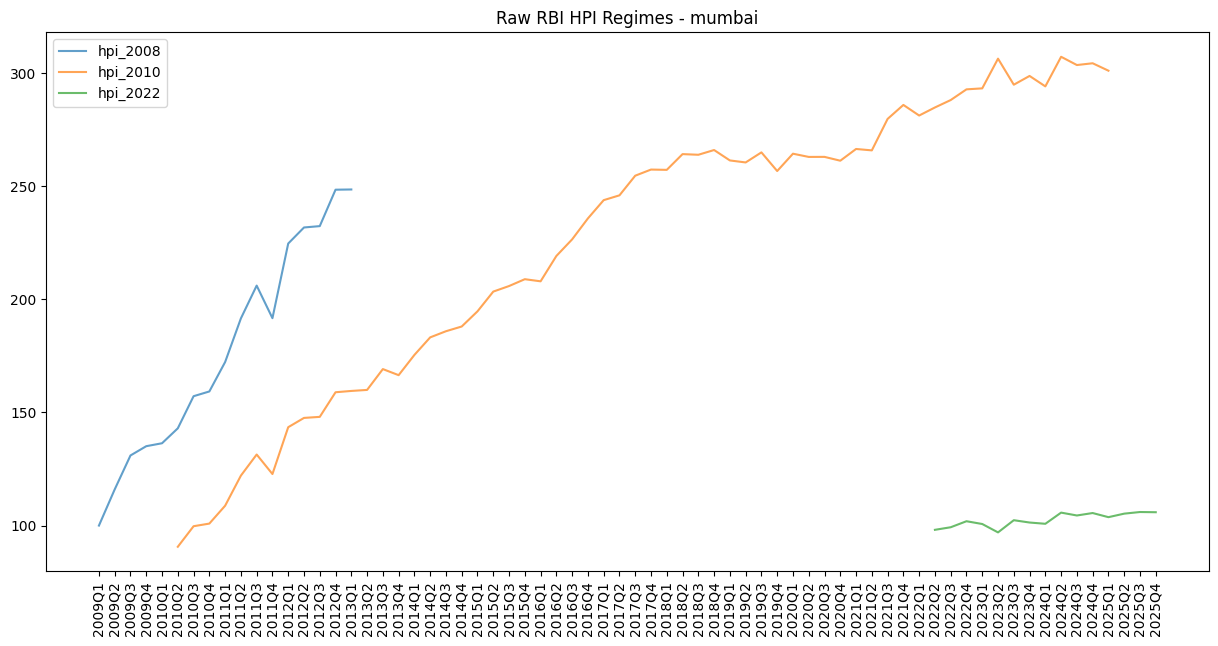

In [23]:
city = 'mumbai'

plot_df = (
    merged_hpi[merged_hpi['city'] == city]
    .sort_values('quarter_period')
)

raw_cols = [
    c for c in merged_hpi.columns
    if c.startswith('hpi_')
]

plt.figure(figsize=(15,7))

for col in raw_cols:

    plt.plot(
        plot_df['quarter_period'].astype(str),
        plot_df[col],
        label=col,
        alpha=0.7
    )

plt.legend()
plt.xticks(rotation=90)
plt.title(f"Raw RBI HPI Regimes - {city}")

plt.show()